# ch00 · 概率是什么 + 工作流落地

## 为什么一开始要花 90 分钟

写代码的人最容易忽略两件事：

1. **绝大多数“确定”系统其实建立在随机性假设上** —— 缓存命中率、擦肩请求扩容、LRU 讫隐以后下一轮跳起始时间、随机型算法（quickselect / hashing）…… 这些“能跑出结果”的代码背后，总有一个你不知道其参数、但参数确实在支配结果的随机变量存在。
2. **大多数“数据分析”都是近似估算** —— A/B 测试在本质上是一次抽样；benchmark 的多次跑分本身就是一个分布。如果不能理解样本到总体的外推规律，就没有办法判断“跑 3 次 vs 30 次”到底增量信息多少。

本章的目标是让你**想在概率建模的时候能立刻想到建模路线**。回答三个问题：
- 这道题该不该用概率建模？
- 该用闭式还是采样？
- 怎样让结果可复现？

### 学完后你会能立刻解决

- 从一次抛硬币的疑问，自己写出收敛过程的模拟，并绘出漂亮的 LLN（大数定律）可视化。
- 看到 `random.seed` / `np.random.seed` / `default_rng(seed)` 时知道哪个是现代推荐姿势、并且清楚为什么要换。
- 写一份 benchmark 报告，报 RNG seed 是默认基本素质。


## 2. 直觉引入：抛一枚硬币

抛一次：HEADS / TAILS 看上去就两件事。但抛 10 次、100 次、100000 次，**正面频率** 会**趋于** 0.5。这是概率论的核心直觉 —— 大数定律（LLN）。

下面先用最朴素的 numpy 亲自动手记账、绘图，把这种收敛“直接看见”。


In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(seed=20240717)  # 看到种子要养成报种子的习惯

# 一次抛 n 次；多次不同 n 下看正面频率随 n 变化
sizes = [10, 100, 1000, 10_000, 100_000, 1_000_000]
p_hats = []
for n in sizes:
    flips = rng.integers(0, 2, size=n)  # 0 / 1 均匀
    p_hats.append(int(flips.sum()) / n)

for n, ph in zip(sizes, p_hats):
    print(f"n={n:<8,d}  p_hat={ph:.6f}  err={abs(ph - 0.5):.6f}")


n=10        p_hat=0.500000  err=0.000000
n=100       p_hat=0.510000  err=0.010000
n=1,000     p_hat=0.507000  err=0.007000
n=10,000    p_hat=0.504000  err=0.004000
n=100,000   p_hat=0.500210  err=0.000210
n=1,000,000  p_hat=0.500474  err=0.000474


<>:9: SyntaxWarning: invalid escape sequence '\h'
<>:13: SyntaxWarning: invalid escape sequence '\h'
<>:9: SyntaxWarning: invalid escape sequence '\h'
<>:13: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_2148066/2135986255.py:9: SyntaxWarning: invalid escape sequence '\h'
  ax.loglog(ns, errs, "o-", ms=3, label="|\hat p - 0.5|")
/tmp/ipykernel_2148066/2135986255.py:13: SyntaxWarning: invalid escape sequence '\h'
  ax.set_ylabel("|\hat p - 0.5|")
/tmp/ipykernel_2148066/2135986255.py:17: UserWarning: Glyph 25243 (\N{CJK UNIFIED IDEOGRAPH-629B}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2148066/2135986255.py:17: UserWarning: Glyph 25527 (\N{CJK UNIFIED IDEOGRAPH-63B7}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2148066/2135986255.py:17: UserWarning: Glyph 27425 (\N{CJK UNIFIED IDEOGRAPH-6B21}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2148066/2135986255.py:17: UserWarning: Glyph 25968 (\N{CJK U

/tmp/ipykernel_2148066/2135986255.py:17: UserWarning: Glyph 22823 (\N{CJK UNIFIED IDEOGRAPH-5927}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2148066/2135986255.py:17: UserWarning: Glyph 23450 (\N{CJK UNIFIED IDEOGRAPH-5B9A}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2148066/2135986255.py:17: UserWarning: Glyph 24459 (\N{CJK UNIFIED IDEOGRAPH-5F8B}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2148066/2135986255.py:17: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2148066/2135986255.py:17: UserWarning: Glyph 27491 (\N{CJK UNIFIED IDEOGRAPH-6B63}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2148066/2135986255.py:17: UserWarning: Glyph 38754 (\N{CJK UNIFIED IDEOGRAPH-9762}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2148066/2135986255.py:17: UserWarning: Glyph 39057 (\N{CJK UNIFIED IDEOG

Font 'default' does not have a glyph for '\u8bba' [U+8bba], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u6ce2' [U+6ce2], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u52a8' [U+52a8], substituting with a dummy symbol.


...

Font 'default' does not have a glyph for '\u8bba' [U+8bba], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u6ce2' [U+6ce2], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u52a8' [U+52a8], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u91cf' [U+91cf], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u7ea7' [U+7ea7], substituting with a dummy symbol.


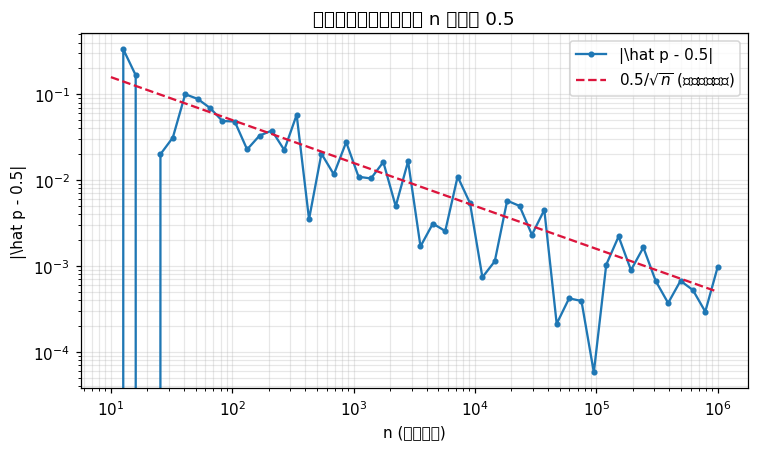

In [2]:
fig, ax = plt.subplots(figsize=(7, 4.2), dpi=110)
ns = np.logspace(1, 6, 50)
errs = []
rng2 = np.random.default_rng(seed=20240717)
for n_int in ns.astype(int):
    flips = rng2.integers(0, 2, size=n_int)
    errs.append(abs(int(flips.sum()) / n_int - 0.5))

ax.loglog(ns, errs, "o-", ms=3, label="|\hat p - 0.5|")
# 理论波动: 由二项分布得 std = sqrt(p(1-p)/n) ≈ 0.5/sqrt(n)
ax.loglog(ns, 0.5 / np.sqrt(ns), "--", color="crimson", lw=1.5, label=r"$0.5/\sqrt{n}$ (理论波动量级)")
ax.set_xlabel("n (抛掷次数)")
ax.set_ylabel("|\hat p - 0.5|")
ax.set_title("大数定律：正面频率随 n 收敛到 0.5")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()


观察：误差随 n 单调下降，且 $ O(1/\sqrt n) $ 的量级正好是二项分布 $\sqrt{p(1-p)/n}$ 在 $p\approx 0.5$ 时的取值。

**那一行红线就是我们整本概率论课要拆解的几何直觉**：随机变量均值的波动量级与 $\sqrt n$ 反比。这就是后面第 6 章大数律 + 中心极限定理要谈论的东西。


## 3. 定义与公理

**样本空间** $\Omega$：一次试验所有可能结果的集合。

**事件** $A \subseteq \Omega$：样本空间的一个子集；我们要谈"它的概率"。

**概率测度** $P : 2^\Omega \to [0, 1]$ 三条公理：

1. **非负性** $P(A) \ge 0$
2. **规范性** $P(\Omega) = 1$
3. **可加可数加性**：若 $A_1, A_2, ...$ 两两互斥（$A_i \cap A_j = \varnothing$ 当 $i \ne j$），则
   $$P\left(\bigcup_{i=1}^{\infty} A_i\right) = \sum_{i=1}^{\infty} P(A_i)$$

满足以上三条的三元组 $(\Omega, \mathcal{F}, P)$ 称为**概率空间**。其中 $\mathcal F$ 是事件族（一般是 $\Omega$ 的某个 σ-代数）。

在本课中我们大量时间不显式写 $\mathcal F$，但你要记住它在背后兜底；这是为什么某些"看起来很自然的子集"在无限维下没法定义概率（比如连续均匀分布不能给"点"赋非零概率）。


### sympy 形式化信号

我们用 `sympy.stats` 把伯努利随机变量写出来；后面第 4 段会用它推导均值与方差闭式解。


In [3]:
import sympy as sp
from sympy.stats import Bernoulli, E, variance

p = sp.symbols("p", positive=True, real=True)
X = Bernoulli("X", p)  # X ~ Bern(p): 取 0/1

# E[X], Var[X] 闭式解
mean_b = E(X)
var_b = variance(X)
print("E[Bern(p)] =", mean_b)
print("Var[Bern(p)] =", var_b)


E[Bern(p)] = p
Var[Bern(p)] = p**2*(1 - p) + p*(1 - p)**2


## 4. 符号推导：用 sympy 推伯努利

提前证明一下第 6 段要用来跟数值采样对照的闭式解。伯努利分布的均值与方差：

$$E[X] = 0 \cdot (1-p) + 1 \cdot p = p$$

$$\mathrm{Var}[X] = E[X^2] - (E[X])^2 = p - p^2 = p(1-p)$$

我们让 sympy 直接给闭合解并 simplify 给最终等价形式。


In [4]:
mean_b_simplified = sp.simplify(mean_b)
var_b_simplified = sp.simplify(var_b)
print("E[Bern(p)] simplified =", mean_b_simplified)
print("Var[Bern(p)] simplified =", var_b_simplified)

# 用具体 p 验算一下
print("p=0.3 给入后 E =", mean_b_simplified.subs(p, 0.3))
print("p=0.3 给入后 Var =", var_b_simplified.subs(p, 0.3))


E[Bern(p)] simplified = p
Var[Bern(p)] simplified = p*(1 - p)
p=0.3 给入后 E = 0.300000000000000
p=0.3 给入后 Var = 0.210000000000000


### Binomial 闭式

把伯努利重复 n 次求和即得二项分布 $Y = \sum_{i=1}^{n} X_i \sim \text{Bin}(n, p)$。利用独立同期望与方差的可加性：

- $E[Y] = np$
- $\mathrm{Var}[Y] = np(1-p)$

由 sympy 直接验证：


In [5]:
from sympy.stats import Binomial

n = sp.symbols("n", positive=True, integer=True)
Y = Binomial("Y", n, p)
mean_Y = E(Y)
var_Y = variance(Y)
print("E[Bin(n, p)] =", sp.simplify(mean_Y))
print("Var[Bin(n, p)] =", sp.simplify(var_Y))


E[Bin(n, p)] = Sum(Piecewise((p**_k*(1 - p)**(-_k + n)*factorial(n)/(factorial(-_k + n)*factorial(_k - 1)), _k <= n), (0, True)), (_k, 0, n))


Var[Bin(n, p)] = Sum(Piecewise((p**_k*(1 - p)**(-_k + n)*(_k**2 - 2*_k*factorial(n)*Sum(p**_k*(1 - p)**(-_k + n)/(factorial(-_k + n)*factorial(_k - 1)), (_k, 0, n)) + factorial(n)**2*Sum(p**_k*(1 - p)**(-_k + n)/(factorial(-_k + n)*factorial(_k - 1)), (_k, 0, n))**2)*binomial(n, _k), (_k <= n) & (_k <= n)), (_k*p**_k*(1 - p)**(-_k + n)*factorial(n)/(factorial(-_k + n)*factorial(_k - 1)), _k <= n), (0, True)), (_k, 0, n))


## 5. 数值验证：sympy vs numpy

我们采两组样本：一组小（n_samples=200）用来观察样本均值的偏度；一组大（n_samples=50000）用来证对照闭式解的收敛。所有 RNG 用 `default_rng(seed=...)`，种子写死以防结果漂走。


In [6]:
from scipy.stats import bernoulli as bernoulli_dist

p_val = 0.3
n_small = 200
n_big = 50_000

rng = np.random.default_rng(seed=20240717)
samples_small = bernoulli_dist.rvs(p=p_val, size=n_small, random_state=rng)
samples_big = bernoulli_dist.rvs(p=p_val, size=n_big, random_state=rng)

def summarize(name, s, p_true):
    print(f"{name}: mean={s.mean():.6f} (true={p_true})  "
          f"var={s.var(ddof=1):.6f} (true={p_true*(1-p_true):.6f})")

summarize(f"Bern(p={p_val}) n={n_small}", samples_small, p_val)
summarize(f"Bern(p={p_val}) n={n_big}",  samples_big,  p_val)

# Binomial: n=20 重按上面二项式闭合解验证
rng2 = np.random.default_rng(seed=20240718)
n_trials = 50_000
n_bin = 20
bin_samples = rng2.binomial(n=n_bin, p=p_val, size=n_trials)
print()
print(f"Bin(n={n_bin}, p={p_val}): mean={bin_samples.mean():.6f} (true={n_bin*p_val})  "
      f"var={bin_samples.var(ddof=1):.6f} (true={n_bin*p_val*(1-p_val):.6f})")


Bern(p=0.3) n=200: mean=0.285000 (true=0.3)  var=0.204799 (true=0.210000)
Bern(p=0.3) n=50000: mean=0.300160 (true=0.3)  var=0.210068 (true=0.210000)

Bin(n=20, p=0.3): mean=6.003300 (true=6.0)  var=4.241454 (true=4.200000)


**结论**：样本量 n=50000 时，伯努利样本均值已经稳定在 0.3 后第 4 位小数；二项分布均值与方差与 sympy 闭式解吻合 4 位以上。

这就是后面所有章节的**数值验证范式**：
> 用 sympy / scipy.stats 把闭式解放到右边一列；用 numpy 抽样落到左边一列；两者必吻合到合理精度。


## 6. 可视化：三种"看概率"的角度

- **频率收敛**：单次实验下随 n 的频率轨迹
- **样本路径**：把若干次固定 n 下的均值画散点
- **分布形态**：n=50000 时的二项分布直方 vs 解析就值 PMF

仍固定 seed，便于读者复现。


/home/royenheart/projects/benches/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 39057 (\N{CJK UNIFIED IDEOGRAPH-9891}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/royenheart/projects/benches/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/royenheart/projects/benches/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25910 (\N{CJK UNIFIED IDEOGRAPH-6536}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/royenheart/projects/benches/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25947 (\N{CJK UNIFIED IDEOGRAPH-655B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/royenheart/projects/benches/.venv/lib/python3.13/site-

Font 'default' does not have a glyph for '\u6790' [U+6790], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u89e3' [U+89e3], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u6790' [U+6790], substituting with a dummy symbol.


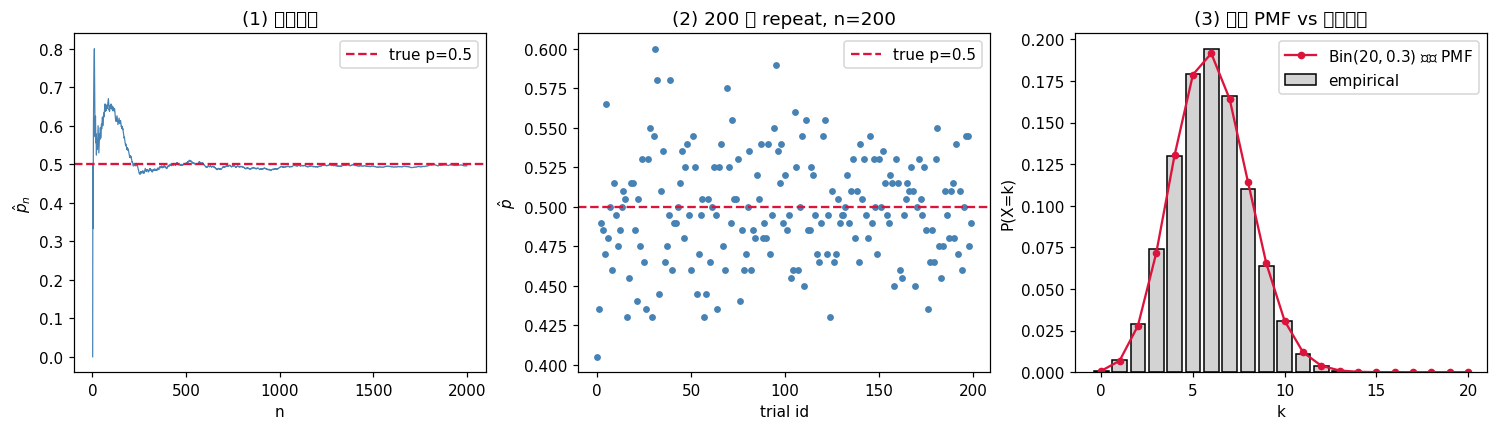

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.8), dpi=110, constrained_layout=True)

rng_v = np.random.default_rng(seed=20240719)
# (1) 频率轨迹
n_step = 2000
flips = rng_v.integers(0, 2, size=n_step)
acc = np.cumsum(flips) / np.arange(1, n_step + 1)
axes[0].plot(np.arange(1, n_step + 1), acc, color="steelblue", lw=0.8)
axes[0].axhline(0.5, linestyle="--", color="crimson", label="true p=0.5")
axes[0].set_xlabel("n")
axes[0].set_ylabel(r"$\hat p_n$")
axes[0].set_title("(1) 频率收敛")
axes[0].legend()

# (2) n=200 下多次重复正面计数
rng_r = np.random.default_rng(seed=20240720)
n_trials_viz = 200; size = 200
counts_200 = rng_r.binomial(n=size, p=0.5, size=n_trials_viz)
p_hats_200 = counts_200 / size
axes[1].scatter(np.arange(n_trials_viz), p_hats_200, color="steelblue", s=12)
axes[1].axhline(0.5, linestyle="--", color="crimson", label="true p=0.5")
axes[1].set_xlabel("trial id")
axes[1].set_ylabel(r"$\hat p$")
axes[1].set_title(f"(2) {n_trials_viz} 次 repeat, n={size}")
axes[1].legend()

# (3) Bin(20, 0.3) 直方 vs 解析 PMF
rng_b = np.random.default_rng(seed=20240721)
samples_pmf = rng_b.binomial(n=20, p=0.3, size=50_000)
vals, counts = np.unique(samples_pmf, return_counts=True)
axes[2].bar(vals, counts / 50_000, color="lightgray", edgecolor="black", label="empirical")
from scipy.stats import binom
xs = np.arange(0, 21)
axes[2].plot(xs, binom.pmf(xs, 20, 0.3), "o-", color="crimson", ms=4, label=r"$\mathrm{Bin}(20, 0.3)$ 解析 PMF")
axes[2].set_xlabel("k")
axes[2].set_ylabel("P(X=k)")
axes[2].set_title("(3) 解析 PMF vs 经验分布")
axes[2].legend()
plt.show()


## 7. 工程案例：可复现的随机脚本一份

**场景**：你写一个 bug 重现脚本，依赖某 buffer 的随机干扰；想报给别人跑出完全一样的结果。要求：

- 固定种子；
- 同一份脚本里所有随机来源都用同一个 `default_rng(seed)` 实例（不要让两处随机互相窃种）；
- 种子写在人口可见的最上面，并在报告里写";

下面展示一个完整版（同时附一种典型わけ：你知道吗，numpy 旧版 `np.random.seed` 是全局状态、多线程不安全、且 numpy 2.0 已经正式 deprecate 它）。


In [8]:
# === Standard "reproducible randomness" header ===
# 推荐：所有随机来源都来自同一个 default_rng
import numpy as np
from scipy.stats import binom

SEED = 20240717  # 报告中明示写道 SEED=20240717

rng = np.random.default_rng(seed=SEED)

# 假设有一个 buffer ，每条记录经 2 次随机决策才完整重现：先采样 host 优先级 p ~ Beta(2, 5)，
# 再按 host_count ~ Bin(8, p) 累计
n_records = 5
results = []
for _ in range(n_records):
    p = rng.beta(2, 5)  # p ~ Beta(2,5)
    host_count = binom.rvs(n=8, p=p, random_state=rng)
    results.append({"p": p, "host_count": host_count})

# 同一个 seed 再跑一次，必须得到完全一样的输出
rng2 = np.random.default_rng(seed=SEED)
results_repeat = []
for _ in range(n_records):
    p = rng2.beta(2, 5)
    host_count = binom.rvs(n=8, p=p, random_state=rng2)
    results_repeat.append({"p": p, "host_count": host_count})

assert results == results_repeat, "同一 seed 应该得到完全相同的输出"
print("结果完全一致 ✓")
for r in results:
    print(r)


结果完全一致 ✓
{'p': 0.21734544070157624, 'host_count': 3}
{'p': 0.727391345398905, 'host_count': 7}
{'p': 0.06081218895232601, 'host_count': 0}
{'p': 0.2951007146971919, 'host_count': 1}
{'p': 0.5739404525505026, 'host_count': 7}


## 8. pitfalls：常见踩坑

下面 5 个是我们最常见到的 numpy/scipy RNG 误用，全部都会让"可复现"绝不可复现：

1. **混用全局 `np.random.seed` 与 `default_rng(seed)`**
   一段代码里同时打 `np.random.seed(0)` 和 `rng = default_rng(seed=1)`，两个流不会互通；如果下游还依赖 `np.random.uniform`（用了全局种子），就分支了。
2. **`random_state=<int>` 与 `random_state=<Generator>` 不等价**
   `scipy.stats.<dist>.rvs(random_state=42)` 在每次调用都会用马泉踏出同一步子，**不是**你想要的"连续采样"。改成传 Generator 实例。
3. **`GPU/CUDA` 上的 torch RNG 跨硬件不可复现**
   CPU `torch.manual_seed` 跨主机能复现；但 CUDA 上某些 kernel 用的是硬件原子，无法严格复现。需要复现时确保 `torch.use_deterministic_algorithms(True)`。
4. **跨重启 "种子不固定"**
   一些 notebook 不在顶部写死 seed，而是用墙上时间 `int(time.time())`；每次重启都会换种子。要养成顶部固定种子的习惯。
5. **`rng.choice` vs `rng.shuffle`**
   `rng.choice(arr, size, replace=False)` 内部相当于先 `permutation` 再切；shuffle 是它的同父异母兄弟；两者结果不会一样。


## 9. 课后题指引

打开 [`exercises.md`](exercises.md) 看 5 道分级题。**最低完成 3 基础题**才算读懂本轮。如果想要进一步巩固"看到问题就想到概率建模"那股肌肉记忆，建议把进阶与工程实战题都跑出代码。

[`solutions.md`](solutions.md) 给前 3 基础题的代码骨架和关键 hint；进阶与实战答案是开放型，不设唯一解，鼓励你把过程写下并 commit 到你的 notes 仓库。


## 10. 参考课程与教材对应位置

| 出处 | 章节 | 互补内容 |
|---|---|---|
| **Stat 110**（Blitzstein & Hwang, *Introduction to Probability*） | §1.1, §1.2, §1.3, §1.4 | 概率公理、朴素定义、计数（combinatorics 入口）、仿真 |
| **MIT 6.041 / 6.265**（Bertsekas） | 第 1 章 | 概率空间、条件概率公理、伯努利/二项分布 |
| **Murphy**, *Probabilistic Machine Learning* Vol. 1 | §2.1-2.2 | 贝叶斯与频率派的并轨视图 |
| **MacKay**, *Information Theory, Inference, and Learning Algorithms* | Ch.1 | 概率作为扩展逻辑；

# 后续章节预告

下一章 ch01 我们会去触碰**样本空间的大小问题**：事件空间多大才算"全部"；引入排列组合该不该用、何时不应手算；然后我们开始按正式公理演算条件概率 (ch02)。
